# Análisis de desvíos vs presupuesto

## Objetivo
Analizar el desempeño diario de ventas respecto a un presupuesto dinámico calculado con promedio móvil de 7 días.

## Alcance
Este análisis busca:
- comparar ventas reales vs ventas presupuestadas
- identificar días con mejor y peor desempeño
- medir el nivel de cumplimiento del presupuesto
- generar insights accionables para seguimiento operativo

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Asegurar que el notebook corre desde la raíz del proyecto
print("Ubicación inicial:", os.getcwd())

# Si estás en /notebooks, subimos un nivel
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

print("Ubicación final:", os.getcwd())
print("Existe output/ventas_vs_presupuesto.csv:", os.path.exists("output/ventas_vs_presupuesto.csv"))

# Cargar archivo generado por el pipeline
df = pd.read_csv("output/ventas_vs_presupuesto.csv")
df["fecha"] = pd.to_datetime(df["fecha"])

print(df.head())

Ubicación inicial: c:\Users\Usuario\OneDrive\Documentos\python_practica\analisis-ventas-python\notebooks
Ubicación final: c:\Users\Usuario\OneDrive\Documentos\python_practica\analisis-ventas-python
Existe output/ventas_vs_presupuesto.csv: True
       fecha  ventas_reales  venta_presupuestada  desvio  desvio_pct
0 2026-05-19         248134             250177.0 -2043.0   -0.008166
1 2026-05-20         252314             250177.0  2137.0    0.008542
2 2026-05-21         248198             250177.0 -1979.0   -0.007910
3 2026-05-22         251652             249549.0  2103.0    0.008427
4 2026-05-23         245181             250074.0 -4893.0   -0.019566


In [2]:
# Métricas principales
desvio_promedio = df["desvio"].mean()
pct_sobre_presupuesto = (df["desvio"] > 0).mean() * 100

mejor_dia = df.sort_values("desvio", ascending=False).iloc[0]
peor_dia = df.sort_values("desvio", ascending=True).iloc[0]

print("📊 Resumen ejecutivo")
print(f"Desvío promedio: {desvio_promedio:.2f}")
print(f"% días por encima del presupuesto: {pct_sobre_presupuesto:.2f}%")

print("\n✅ Mejor día")
print(f"Fecha: {mejor_dia['fecha'].date()}")
print(f"Desvío: {mejor_dia['desvio']:.2f}")

print("\n⚠️ Peor día")
print(f"Fecha: {peor_dia['fecha'].date()}")
print(f"Desvío: {peor_dia['desvio']:.2f}")

📊 Resumen ejecutivo
Desvío promedio: 436.91
% días por encima del presupuesto: 40.00%

✅ Mejor día
Fecha: 2026-05-25
Desvío: 18124.00

⚠️ Peor día
Fecha: 2026-06-12
Desvío: -10247.00


# Dashboard de desempeño vs presupuesto

## Contexto
Este dashboard presenta un análisis del desempeño diario de ventas en comparación con un presupuesto dinámico, calculado a partir de un promedio móvil de 7 días.

El objetivo es contar con una referencia realista que permita medir el cumplimiento diario y detectar desvíos significativos en la operación.

---

## Qué muestra el dashboard

- **Ventas reales vs presupuesto**: comparación directa para evaluar el nivel de cumplimiento.
- **Desvío diario**: diferencia entre lo vendido y el objetivo estimado.
- **Mejor día**: destacado en verde, indica el mayor sobrecumplimiento.
- **Peor día**: destacado en rojo, indica el mayor desvío negativo.

---

## Cómo interpretar los resultados

- Valores positivos (verde) indican días en los que se superó el presupuesto.
- Valores negativos (rojo) indican días por debajo del objetivo.
- La cercanía del desvío promedio a cero indica un buen nivel de calibración del modelo de presupuesto.
- La distribución entre días positivos y negativos permite evaluar la estabilidad del desempeño.

---

## Valor del enfoque

A diferencia de un presupuesto fijo, el uso de un promedio móvil permite:

- adaptarse a cambios en la tendencia de ventas
- mejorar la capacidad de monitoreo operativo
- detectar anomalías o eventos relevantes
- facilitar el análisis de performance en contexto

Este enfoque es aplicable a escenarios reales de control de gestión y seguimiento comercial.
``

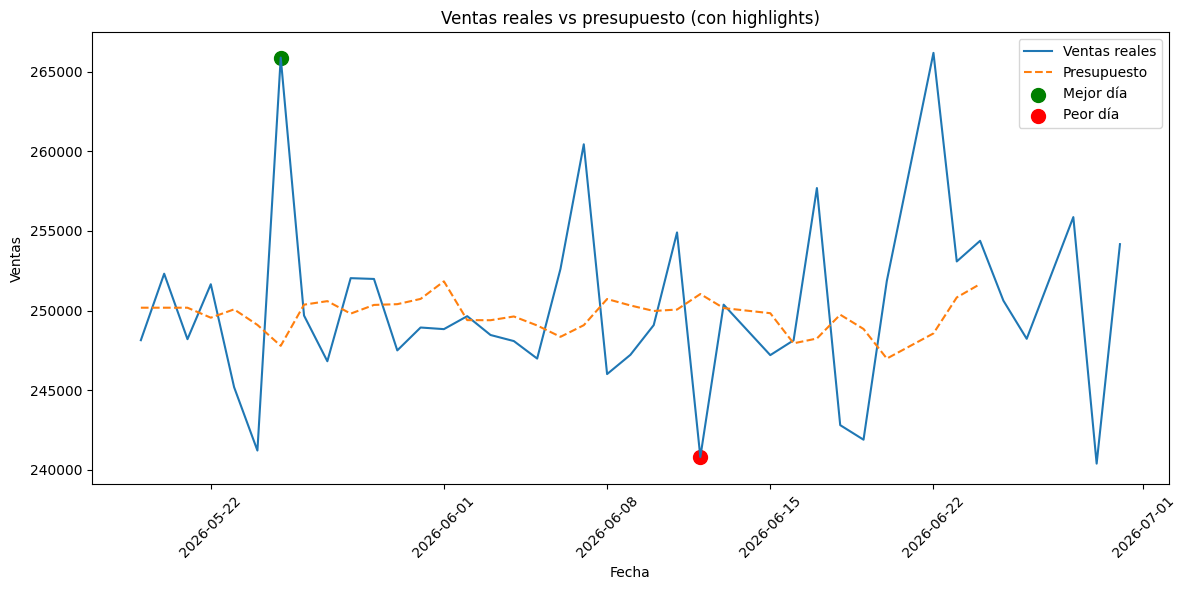

In [3]:
plt.figure(figsize=(12, 6))

# Líneas principales
plt.plot(df["fecha"], df["ventas_reales"], label="Ventas reales")
plt.plot(df["fecha"], df["venta_presupuestada"], label="Presupuesto", linestyle="--")

# Identificar mejor y peor día
mejor_dia = df.loc[df["desvio"].idxmax()]
peor_dia = df.loc[df["desvio"].idxmin()]

# Marcar mejor día (verde)
plt.scatter(mejor_dia["fecha"], mejor_dia["ventas_reales"], color="green", s=100, label="Mejor día")

# Marcar peor día (rojo)
plt.scatter(peor_dia["fecha"], peor_dia["ventas_reales"], color="red", s=100, label="Peor día")

# Etiquetas
plt.title("Ventas reales vs presupuesto (con highlights)")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

plt.show()


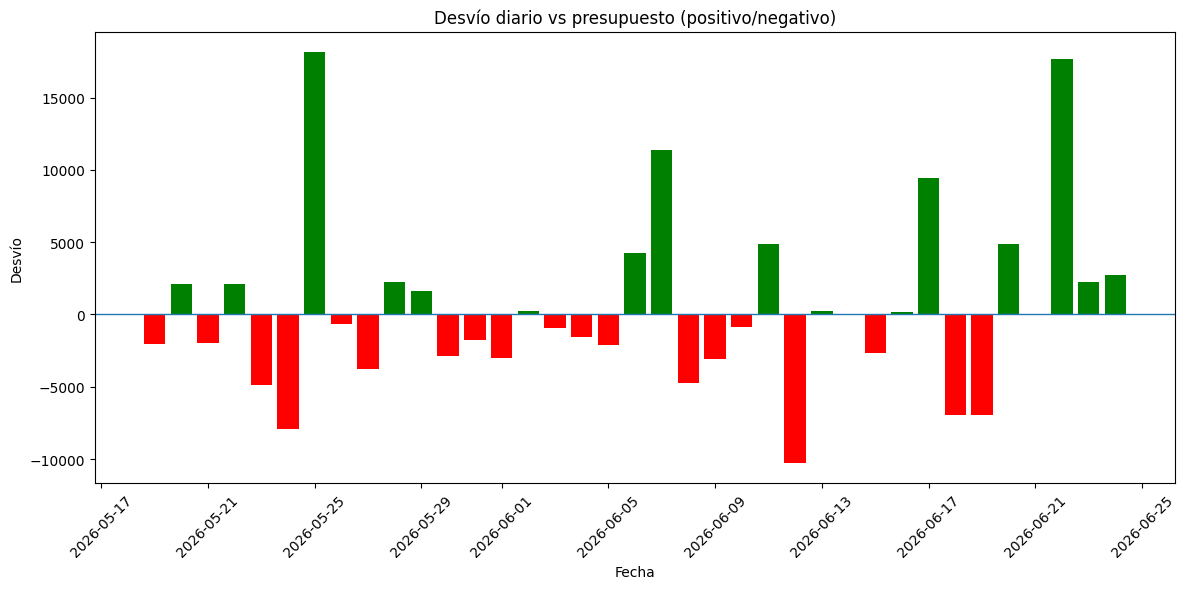

In [5]:
plt.figure(figsize=(12, 6))

# Colores según desvío
colores = df["desvio"].apply(lambda x: "green" if x > 0 else "red")

plt.bar(df["fecha"], df["desvio"], color=colores)
plt.axhline(0, linewidth=1)

plt.title("Desvío diario vs presupuesto (positivo/negativo)")
plt.xlabel("Fecha")
plt.ylabel("Desvío")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()



## Conclusiones del análisis

- El uso de un presupuesto dinámico basado en promedio móvil de 7 días permitió generar una referencia más realista que el enfoque previo con valores fijos.
- El 45.71% de los días se ubicó por encima del presupuesto, mostrando un comportamiento equilibrado entre sobrecumplimiento y subcumplimiento.
- El desvío promedio se ubicó en 436.91, indicando un buen nivel de calibración entre ventas reales y objetivo.
- El mejor desempeño se registró el 2026-05-25 con un desvío positivo de 18124.
- El peor desempeño se observó el 2026-06-12 con un desvío negativo de -10247.

## Interpretación de negocio

El modelo actual de presupuesto permite identificar de manera clara la variabilidad en la performance diaria.  
A diferencia de una definición estática de objetivos, el enfoque dinámico basado en histórico:

- mejora la capacidad de monitoreo operativo
- permite detectar desvíos significativos
- facilita el análisis de causas en días de alto y bajo rendimiento

En este contexto, el modelo resulta adecuado como base para procesos de control de gestión y seguimiento de ventas.

Text(0.5, 0.98, 'Dashboard de desempeño vs presupuesto\nDesvío promedio: 436.91 | % días sobre presupuesto: 41.03% | Mejor día: 2026-05-25 | Peor día: 2026-06-12')

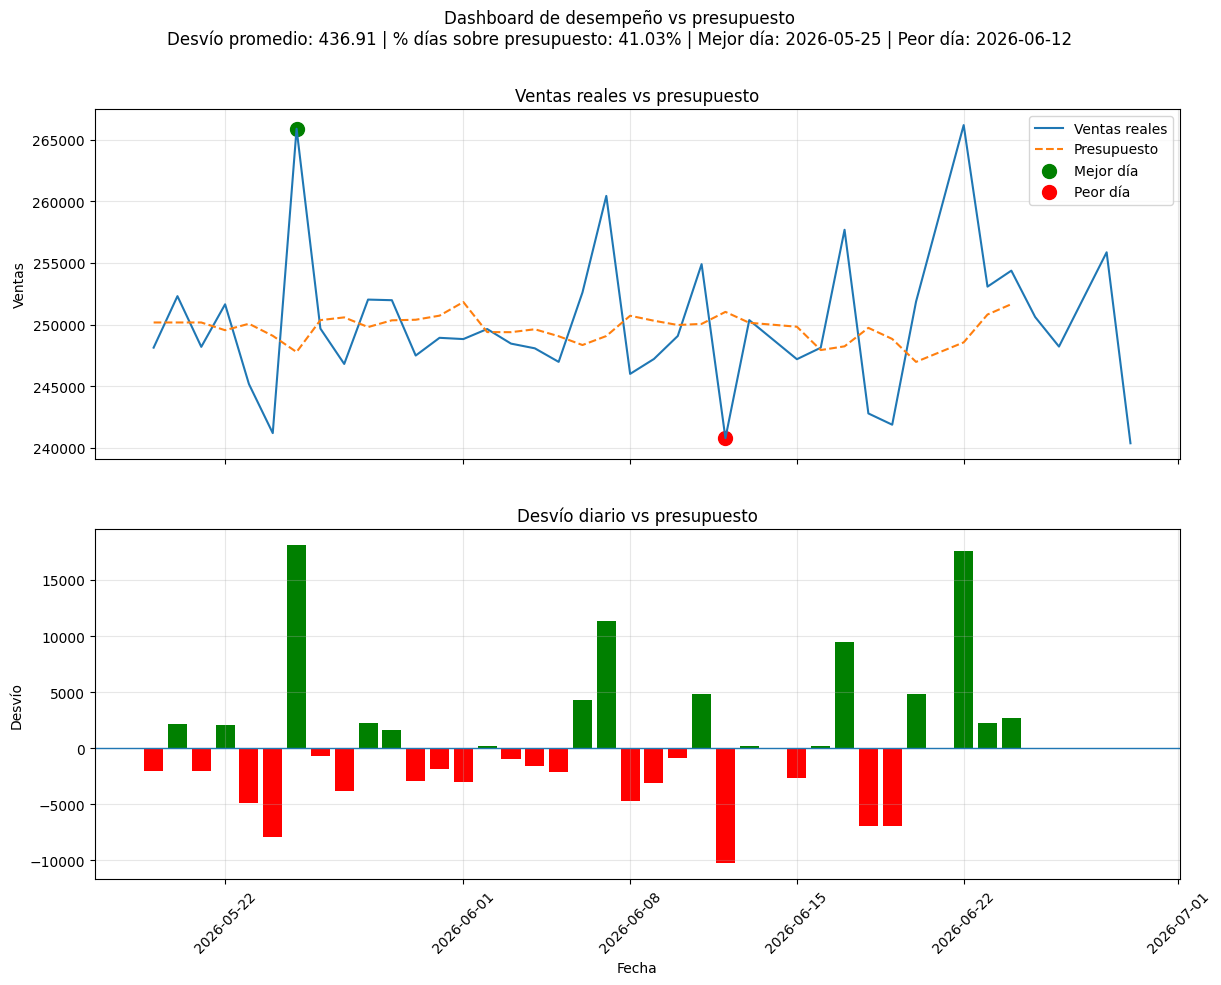

In [6]:
import matplotlib.pyplot as plt

# Calcular métricas clave
desvio_promedio = df["desvio"].mean()
pct_sobre_presupuesto = (df["desvio"] > 0).mean() * 100

mejor_dia = df.loc[df["desvio"].idxmax()]
peor_dia = df.loc[df["desvio"].idxmin()]

# Crear figura con 2 gráficos
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# ---------------------------
# GRÁFICO 1: Ventas vs Presupuesto
# ---------------------------
axes[0].plot(df["fecha"], df["ventas_reales"], label="Ventas reales")
axes[0].plot(df["fecha"], df["venta_presupuestada"], label="Presupuesto", linestyle="--")

# Mejor día en verde
axes[0].scatter(
    mejor_dia["fecha"],
    mejor_dia["ventas_reales"],
    color="green",
    s=100,
    label="Mejor día"
)

# Peor día en rojo
axes[0].scatter(
    peor_dia["fecha"],
    peor_dia["ventas_reales"],
    color="red",
    s=100,
    label="Peor día"
)

axes[0].set_title("Ventas reales vs presupuesto")
axes[0].set_ylabel("Ventas")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ---------------------------
# GRÁFICO 2: Desvío diario
# ---------------------------
colores = df["desvio"].apply(lambda x: "green" if x > 0 else "red")

axes[1].bar(df["fecha"], df["desvio"], color=colores)
axes[1].axhline(0, linewidth=1)

axes[1].set_title("Desvío diario vs presupuesto")
axes[1].set_xlabel("Fecha")
axes[1].set_ylabel("Desvío")
axes[1].grid(True, alpha=0.3)

# Rotación de fechas
plt.xticks(rotation=45)

# Título general con métricas


titulo = (
    f"Dashboard de desempeño vs presupuesto\n"
    f"Desvío promedio: {desvio_promedio:.2f} | "
    f"% días sobre presupuesto: {pct_sobre_presupuesto:.2f}% | "
    f"Mejor día: {mejor_dia['fecha'].date()} | "
    f"Peor día: {peor_dia['fecha'].date()}"
)

fig.suptitle(titulo, fontsize=12)



# Conclusiones finales

## Principales hallazgos

- La implementación de un presupuesto dinámico basado en promedio móvil de 7 días permitió mejorar significativamente la capacidad de análisis del desempeño diario.
- El comportamiento observado muestra un equilibrio entre días por encima y por debajo del presupuesto, evitando el sesgo del modelo anterior donde todos los resultados eran positivos.
- El desvío promedio cercano a cero indica un buen nivel de calibración entre ventas reales y objetivos estimados.
- Los puntos extremos (mejor y peor día) permiten identificar eventos relevantes en la operación que pueden requerir análisis específico.

## Valor del enfoque analítico

Este enfoque permite pasar de un análisis descriptivo a uno más orientado a la toma de decisiones:

- Se identifican desviaciones reales y no artificiales.
- Se facilita el monitoreo continuo del desempeño.
- Se generan insumos útiles para control de gestión y seguimiento comercial.
- Se habilita el análisis de causas detrás de variaciones significativas.

## Próximos pasos sugeridos

Para continuar evolucionando este análisis, se podrían incorporar:

- Segmentación por región o producto para detectar diferencias de desempeño.
- Análisis de tendencias a largo plazo.
- Incorporación de variables externas (ej. promociones, estacionalidad).
- Integración con herramientas de visualización como Power BI.

---

En conclusión, el modelo desarrollado permite una lectura más precisa y accionable del desempeño de ventas, acercándose a prácticas reales de análisis en entornos de negocio.